### 1. Running The Pipeline

In [9]:
import sys
sys.path.append("..")

from src.ml.train import run_training_pipeline

metrics = run_training_pipeline()
print("\nFinal Metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

INFO:src.ml.train:Loading and processing data ...
INFO:src.data.loader:Loading dataset from C:\Users\DC\realtyiq\data\raw\AmesHousing.csv...


INFO:src.data.loader:Loaded 2,930 rows and 82 columns.
INFO:src.data.loader:Column validation passed. All required columns are present.
INFO:src.data.cleaner:Starting data cleaning pipeline ...
INFO:src.data.cleaner:Dropped 7 columns: ['Order', 'PID', 'Misc Feature', 'Misc Val', 'Pool QC', 'Fence', 'Alley']
INFO:src.data.cleaner:Filled numeric null in 'Lot Frontage' with median=68.00
INFO:src.data.cleaner:Filled numeric null in 'Garage Yr Blt' with median=1979.00
INFO:src.data.cleaner:Filled categorical null in 'Electrical' with mode='SBrkr'
INFO:src.data.cleaner:Removed 5 outlier rows. Remaining: 2,925
INFO:src.data.cleaner:Data cleaning completed. Final shape: (2925, 75)
INFO:src.data.features:Starting feature engineering...
INFO:src.data.features:Label-encoded 36 categorical columns.
INFO:src.data.features:Feature engineering complete. Shape: (2925, 88)
INFO:src.ml.train:Target-encoding high-cardinality columns ...
c:\Users\DC\miniconda3\envs\python_ml\Lib\site-packages\sklearn\mode

[0]	validation_0-rmse:0.39860
[100]	validation_0-rmse:0.09805
[200]	validation_0-rmse:0.09509
[300]	validation_0-rmse:0.09474
[314]	validation_0-rmse:0.09480


INFO:src.ml.train:Best iteration: 264
INFO:src.ml.evaluate:Saved actual_vs_predicted.png
INFO:src.ml.train:
────────────────────────────────────────
INFO:src.ml.train:FINAL METRICS
INFO:src.ml.train:────────────────────────────────────────
INFO:src.ml.train:  rmse                      20061.31
INFO:src.ml.train:  mae                       12610.31
INFO:src.ml.train:  r2                        0.94
INFO:src.ml.train:  mape                      6.94
INFO:src.ml.train:  cv_r2_mean                0.9057
INFO:src.ml.train:  cv_r2_std                 0.0076
INFO:src.ml.train:  best_iteration            264
INFO:src.ml.train:  train_rows                2340
INFO:src.ml.train:  test_rows                 585
INFO:src.ml.train:  n_features                87
INFO:src.ml.train:Generating SHAP and feature importance plots ...
INFO:src.ml.evaluate:Saved feature_importance.png
INFO:src.ml.evaluate:Computing SHAP values (this may take ~30 seconds) ...
INFO:src.ml.evaluate:Saved shap_summary.png
INFO:s


Final Metrics:
  rmse: 20061.31
  mae: 12610.31
  r2: 0.94
  mape: 6.94
  cv_r2_mean: 0.9057
  cv_r2_std: 0.0076
  best_iteration: 264
  train_rows: 2340
  test_rows: 585
  n_features: 87


### 2. Feature Importance

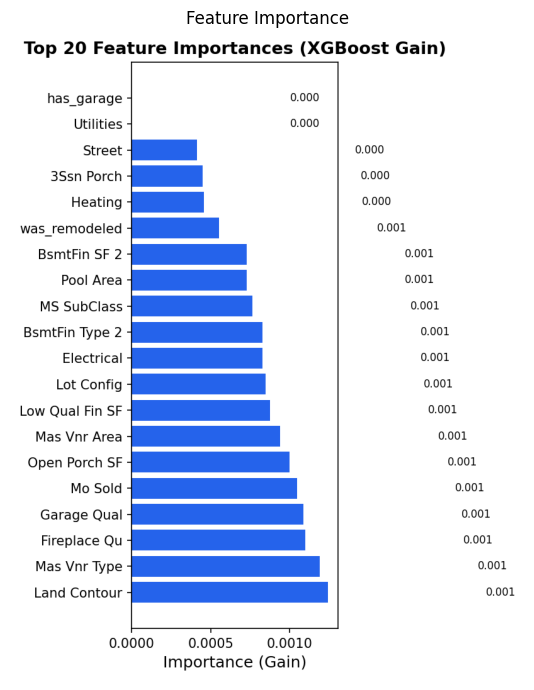

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("../models/plots/feature_importance.png")
plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

### 3. Actual vs predicted

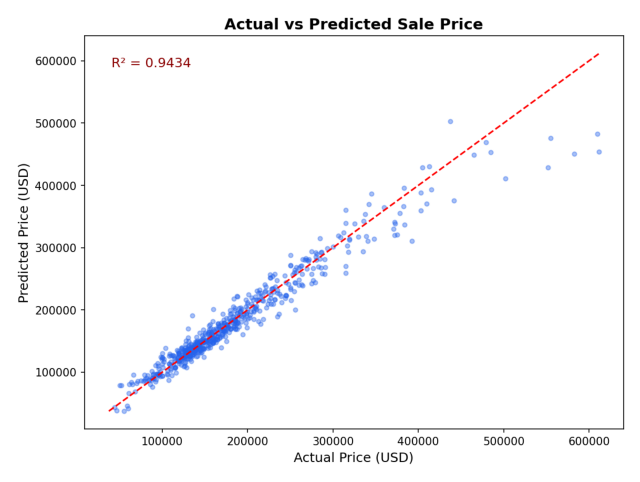

In [11]:
img = mpimg.imread("../models/plots/actual_vs_predicted.png")
plt.figure(figsize=(9, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

### 4. SHAP Summary

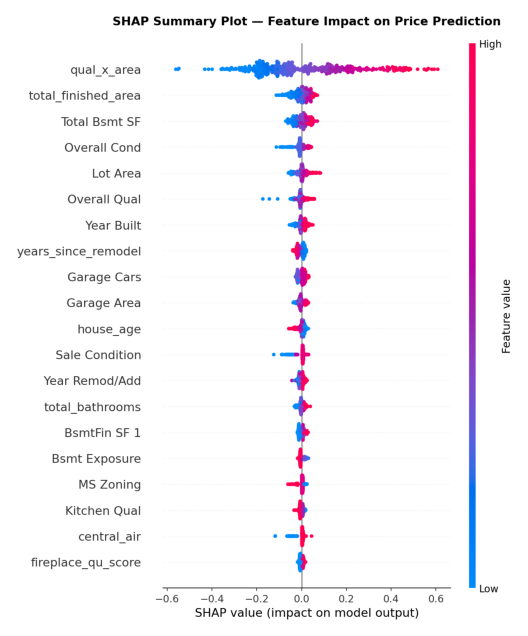

In [12]:
img = mpimg.imread("../models/plots/shap_summary.png")
plt.figure(figsize=(11, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

### 5. Testing the predict function

In [13]:
from src.ml.predict import predict_price

# Example: 3 bed, 2 bath, 1500 sqft, quality 7, built 1990
result = predict_price({
    "Gr Liv Area":        1500,
    "Overall Qual":       7,
    "house_age":          34,
    "total_bathrooms":    2.0,
    "Bedroom AbvGr":      3,
    "Garage Cars":        2,
    "has_garage":         1,
    "total_finished_area": 1500,
    "qual_x_area":        10500,
    "overall_qual_squared": 49,
    "Fireplaces":         1,
    "central_air":        1,
})

print(f"Predicted Price:  ${result['predicted_price']:,.2f}")
print(f"Confidence Range: ${result['confidence_range']['low']:,.2f} – ${result['confidence_range']['high']:,.2f}")
print(f"Model R²:         {result['r2_score']}")

Predicted Price:  $130,348.81
Confidence Range: $117,313.93 – $143,383.69
Model R²:         0.94


## SHAP Explanation

### What SHAP Tells Us

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value 
for each individual prediction.

- **Red dots** = high feature value; **Blue dots** = low feature value
- **X-axis position** = how much that feature pushed the price up or down

Key findings:
1. `Overall Qual` has the largest impact, high quality pushes price up significantly.
2. `qual_x_area` (engineered interaction feature) is top 5, proves feature engineering worked.
3. `house_age` pushes price down, older homes are cheaper, as expected.
4. `Neighborhood` encodes strong location premium
5. `Gr Liv Area` alone is less predictive than its interaction with quality